# Statistics

In [2]:
import json
import matplotlib.pyplot as plt
from pathlib import Path


In [3]:
BASE_DIR = Path("/home/vlada-maric/Desktop/mlProject/nnImgClas/03-evaluation")
OUTPUT_DIR = BASE_DIR / "evaluation_results"

In [4]:
#Funkcija u kojoj crtamo grafike. Prosledjujemo dict koji sadrzi statistike modela
def plot_metric(results, metric_key, ylabel, title, filename):
    models = list(results.keys())
    values = [results[m][metric_key] for m in models]
    x_indices = range(len(models))

    plt.figure(figsize=(10, 5))
    plt.bar(x_indices, values, label=title, color="#000000", width=0.5)

    plt.xticks(ticks=x_indices, labels=models, ha="center")

    plt.xlabel("Models")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()

In [5]:
#Ucitavamo modele
results = {}

with open("eval_convnext.json", "r") as fajl:
    results["ConvNeXt"] = json.load(fajl)

with open("eval_vit.json", "r") as fajl:
    results["ViT"] = json.load(fajl)

with open("eval_swin.json", "r") as fajl:
    results["Swin"] = json.load(fajl)

## Metrike

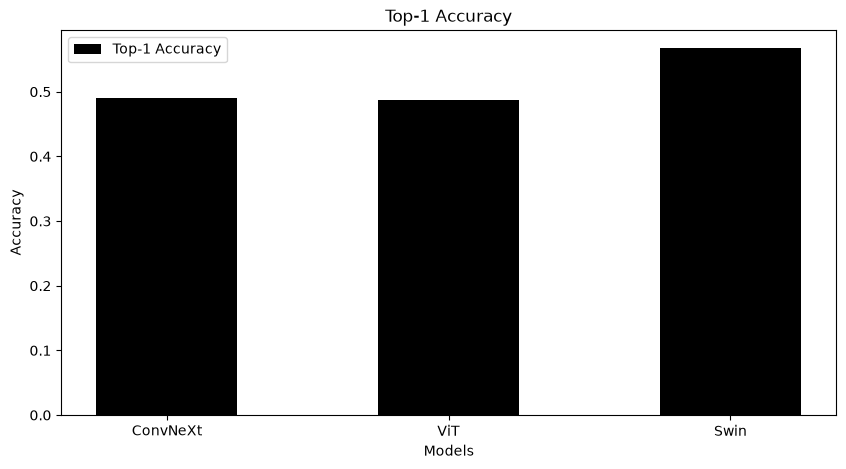

In [6]:
plot_metric(results, "top1_acc", "Accuracy", "Top-1 Accuracy", "top1_acc.png")

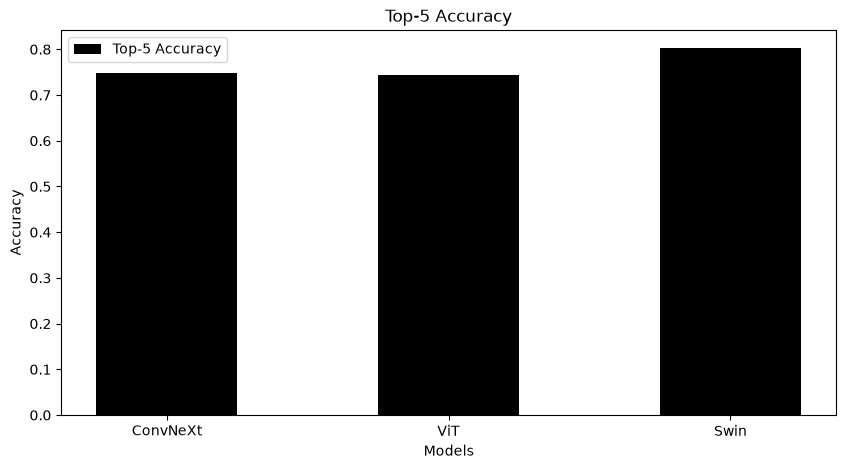

In [7]:
plot_metric(results, "top5_acc", "Accuracy", "Top-5 Accuracy", "top5_acc.png")

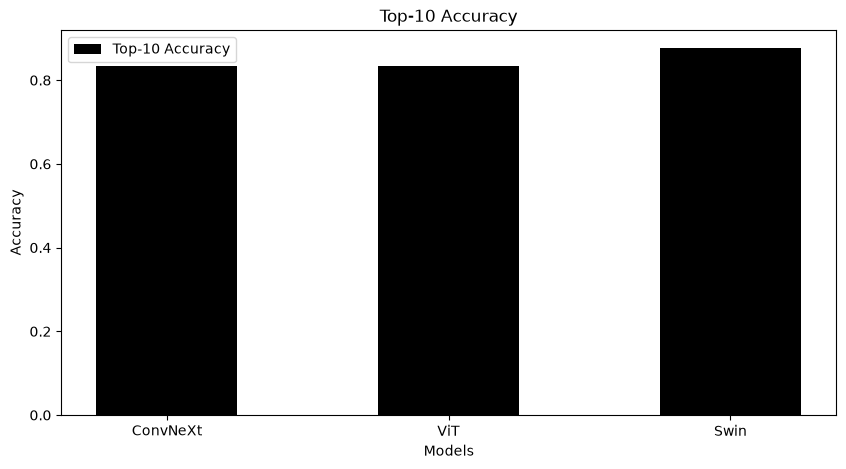

In [8]:
plot_metric(results, "top10_acc", "Accuracy", "Top-10 Accuracy", "top10_acc.png")

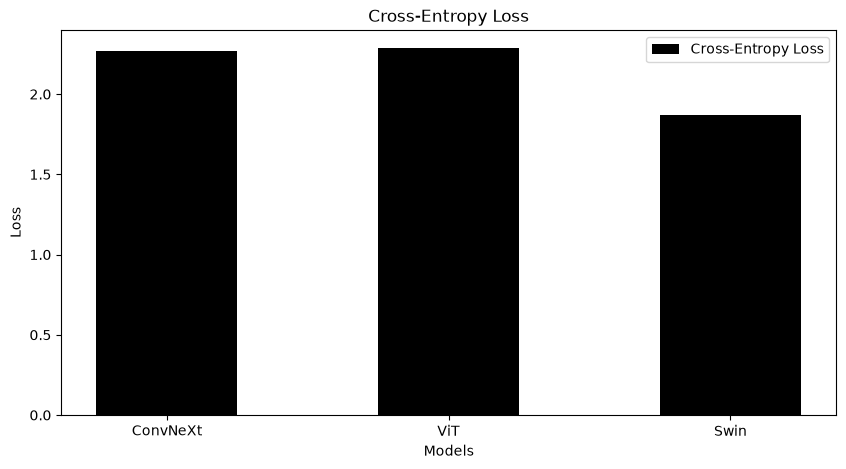

In [9]:
plot_metric(results, "loss", "Loss", "Cross-Entropy Loss", "loss.png")

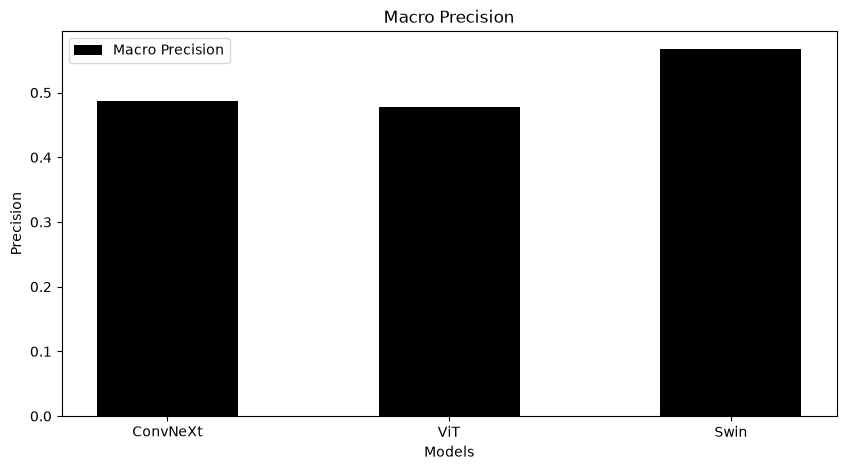

In [10]:
plot_metric(results, "macro_precision", "Precision", "Macro Precision", "macro_precision.png")

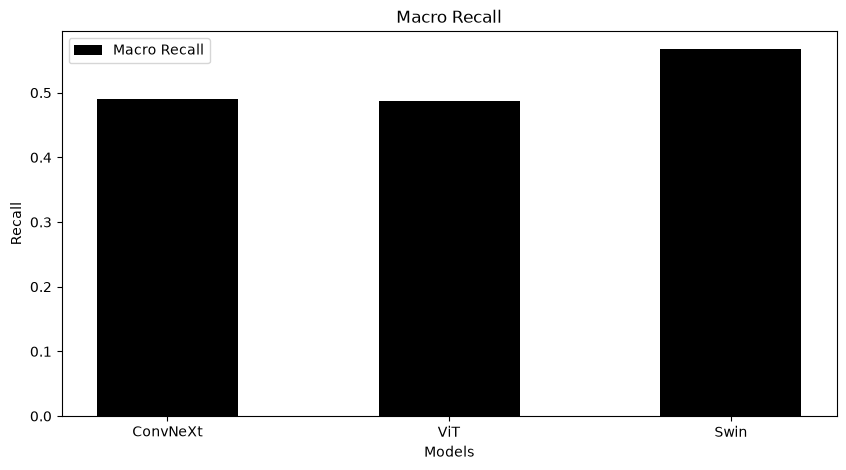

In [11]:
plot_metric(results, "macro_recall", "Recall", "Macro Recall", "macro_recall.png")

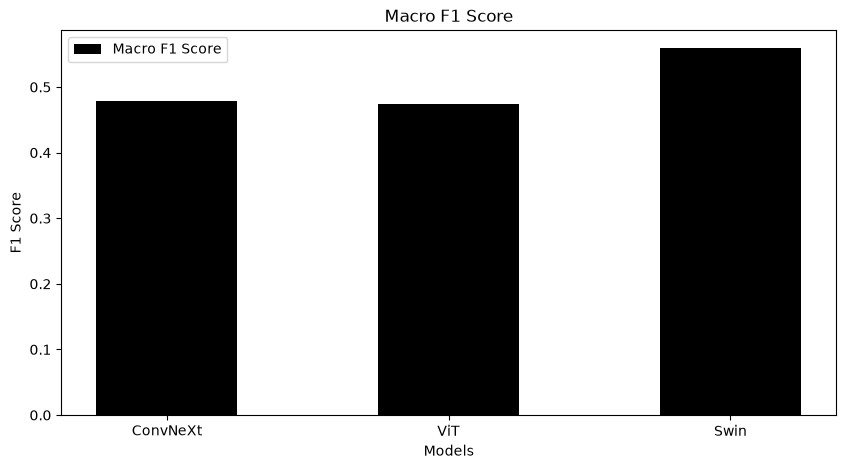

In [12]:
plot_metric(results, "macro_f1", "F1 Score", "Macro F1 Score", "macro_f1.png")

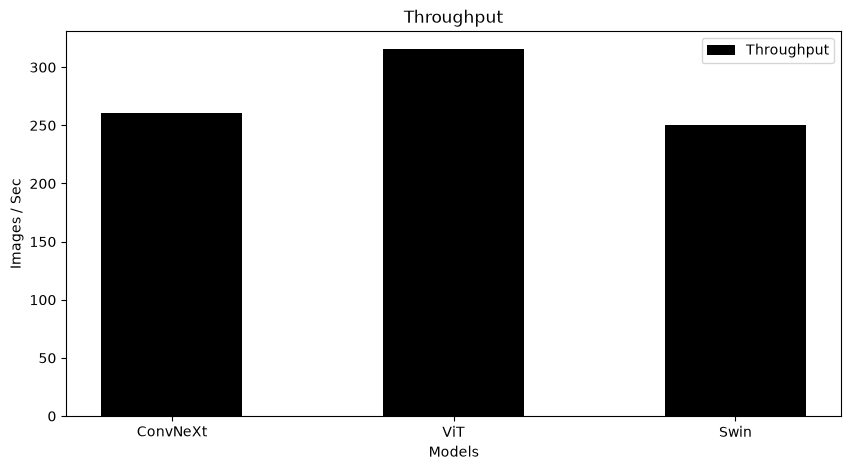

In [13]:
plot_metric(results, "throughput_img_s", "Images / Sec", "Throughput", "throughput_img_s.png")

## Zakljuci

**Swin njbolji model**
Jasno se vidi po svim, osim throughput, metrikama da se Swin arhitektura najbolje pokazala.  

**Regularizacija je dosta poboljsala modele**
S obzirom da su modeli imali accuracy od ne vise od 40% bez regularizacije, a sa oko 50, za Swin arhitekture cak i preko, jasni je da je ona kruicjalna za dobre performanse.

**ConvNeXt i Vit su prakticnt podjednako (ne)kvaltetni**
Jedinu prednost ima ViT, u throughput metrici, po svim ostalim metrikam su iste.

**Potrebno je vise podataka i veci modeli za bolje performanse**
S obzirom da su se koristili parametri i regularizacije koji su se pokazali kao dobri u razlicitim radovima, i da se posle 100 epoha obucavanja, preciznost na validacinom skupi prakticno nije menjala, mozemo doci do zakljucka da je lek vise podatka. Kao i da se koriste modeli sa vecim brojem parametra.